# AUTOENCODER

Los **autoencoders** son un tipo de redes neuronales en las que la entrada y la salida del modelo es la misma, es decir, redes entrenadas para predecir un resultado igual a los datos de entrada.    
   
Para conseguir este tipo de comportamiento, la arquitectura de los **autoencoders** es simétrica, con una región llamada *encoder* y otra *decoder*.     

- ***Codificador/encoder***: comprime los datos de entrada para eliminar cualquier forma de ruido y genera un *espacio latente/cuello de botella (bottleneck)*. Por tanto, las dimensiones de la red neuronal de salida son menores que las de entrada y pueden ajustarse como hiperparámetro para decidir cuánto debe tener de pérdida nuestra compresión.
- ***Decodificador/decoder***: haciendo uso únicamente de la representación comprimida de los datos del *espacio latente*, intenta reconstruir con la mayor fidelidad posible los datos de entrada originales (la arquitectura de esta red neuronal es, por tanto, generalmente una imagen especular del codificador). La "bondad" de la predicción puede medirse calculando el error de reconstrucción entre los datos de entrada y de salida mediante una función de pérdida.   

Repitiendo iterativamente este proceso de pasar datos por el codificador y el descodificador y medir el error para afinar los parámetros mediante retropropagación, el **autoencoder** puede, con el tiempo, trabajar correctamente con formas de datos extremadamente difíciles.

La principal aplicación de los **autoencoders** es captar con precisión los aspectos clave de los datos proporcionados para ofrecer una versión comprimida de los datos de entrada, generar datos sintéticos realistas o señalar anomalías.

## ¿Cómo sirve esto para reducir la dimensionalidad?    

Los autoencoders siguen una arquitectura de cuello de botella, la región encoder está formada por una o varias capas, cada una con menos neuronas que su capa precedente, obligando así a que la información de entrada se vaya comprimiendo.    

En la región decoder esta compresión se revierte siguiendo la misma estructura pero esta vez de menos a más neuronas.   

<img src="/home/jordi/Documentos/Ribera/Curso_25_26/CEIABD/CEIABD_25_26/MODELOS_INTELIGENCIA_ARTIFICIAL_25_26/NOTEBOOKS DEL AULA/img/autoencoder1.png" width=400>   


Para conseguir que la salida reconstruida sea lo más parecida posible a la entrada, el modelo debe aprender a capturar toda la información posible en la zona intermedia. Una vez entrenado, la salida de la capa central del autoencoder (la capa con menos neuronas) es una representación de los datos de entrada pero con una dimensionalidad igual el número de neuronas de esta capa.

La principal ventaja de los autoencoders es que no tienen ninguna restricción en cuanto al tipo de relaciones que pueden aprender, por lo tanto, a diferencia de técnicas como la PCA, la reducción de dimensionalidad puede incluir relaciones no lineales.    

La desventaja es su alto riesgo de sobreentrenamiento (overfitting), por lo que se recomienda emplear muy pocas épocas y siempre evaluar la evolución del error con un conjunto de validación.

En el caso de utilizar funciones de activación lineales, las variables generadas en el cuello de botella (la capa con menos neuronas), son muy similares a las componentes principales de un PCA pero sin que necesariamente tengan que ser ortogonales entre ellas.

Este notebook contiene cuatro ejemplos de autoencoder:    
- conceptos básicos, 
- eliminación de ruido en imágenes,
- detección de anomalías y 
- reducción de dimensionalidad.

## Conceptos básicos.   

Librerías a importar

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

## Carga del primer dataset   

Para empezar, se prepara un ejercicio para un autoencoder básico utilizando el dataset Fashion MNIST. Cada imagen de este dataset tiene 28x28 píxeles.

In [45]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print (x_train.shape)
print (x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


## Primer ejemplo: Autoencoder Básico  

Se define un autocodificador con dos capas densas: un `codificador`, que comprime las imágenes en un vector latente de 64 dimensiones (espacio latente), y un `decodificador`, que reconstruye la imagen original a partir del espacio latente.   

### Nota sobre el tipo de capas a utilizar:    

- **Capas densas (Dense)**    

Se usan cuando los *datos son vectoriales o tabulares*, es decir, cuando no hay una estructura espacial que explotar:

    - Series temporales simples (un vector de valores)
    - Datos tabulares (sensores, métricas, registros)
    - Embeddings de texto
    - Datos ya preprocesados y aplanados

En el caso de imágenes también se pueden usar, como en el teórico y en la práctica, pero con una limitación importante: al aplanar la imagen a un vector de 784 valores se pierde toda la información espacial — el modelo no "sabe" que los píxeles vecinos están relacionados. Funciona, pero es subóptimo.   

- **Capas convolucionales (Conv2D)**    

Se usan cuando los datos tienen *estructura espacial o local*, especialmente ***imágenes***:

El modelo aprende filtros que detectan bordes, texturas, formas… igual que en cualquier CNN.
Los pesos se comparten entre posiciones de la imagen (weight sharing), lo que reduce drásticamente el número de parámetros.
Respetan la geometría 2D: saben que el píxel (14,14) es vecino del (14,15).

En el decoder, la operación simétrica a `Conv2D` es `Conv2DTranspose` (o deconvolución), que reconstruye la resolución espacial progresivamente. &#128076;

*Regla práctica*

| Tipo de dato | Arquitectura recomendada |
|--------------|--------------------------|
| Tabular / vectorial |Dense |
| Imágenes | Conv2D + Conv2DTranspose |     

#### ¿Por qué en la práctica se usan capas `Dense` aun con imágenes?   

Porque el objetivo es entender el concepto sin la complejidad adicional del diseño convolucional. Es perfectamente válido didácticamente. En un proyecto real con imágenes de cierta resolución, un autoencoder convolucional daría reconstrucciones notablemente mejores con muchos menos parámetros.

In [46]:
class Autoencoder(Model):
  def __init__(self, latent_dim, shape):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim
    self.shape = shape
    self.encoder = tf.keras.Sequential([
      layers.Flatten(),
      layers.Dense(latent_dim, activation='relu'),
    ])
    self.decoder = tf.keras.Sequential([
      layers.Dense(tf.math.reduce_prod(shape).numpy(), activation='sigmoid'),
      layers.Reshape(shape)
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded


shape = x_test.shape[1:]
latent_dim = 64
autoencoder = Autoencoder(latent_dim, shape)


Compilación del AUTOENCODER

In [47]:
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

Entrenamiento del modelo    

Se usa el conjunto `x_train` como entrada y como objetivo. El `encoder` aprenderá a comprimir el conjunto de datos de 784 dimensiones al espacio latente, y el `decoder` aprenderá a reconstruir las imágenes originales.

In [48]:
autoencoder.fit(x_train, x_train,
                epochs=10,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0239 - val_loss: 0.0136
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0118 - val_loss: 0.0107
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0101 - val_loss: 0.0098
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0095 - val_loss: 0.0095
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0093 - val_loss: 0.0092
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0091 - val_loss: 0.0091
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0090 - val_loss: 0.0090
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0089 - val_loss: 0.0089
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0088 - val_loss: 0.0089
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0087 - val_loss: 0.0089


Ahora que el modelo está entrenado, se prueba codificando y descodificando imágenes del conjunto de prueba.

In [49]:
encoded_imgs = autoencoder.encoder(x_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

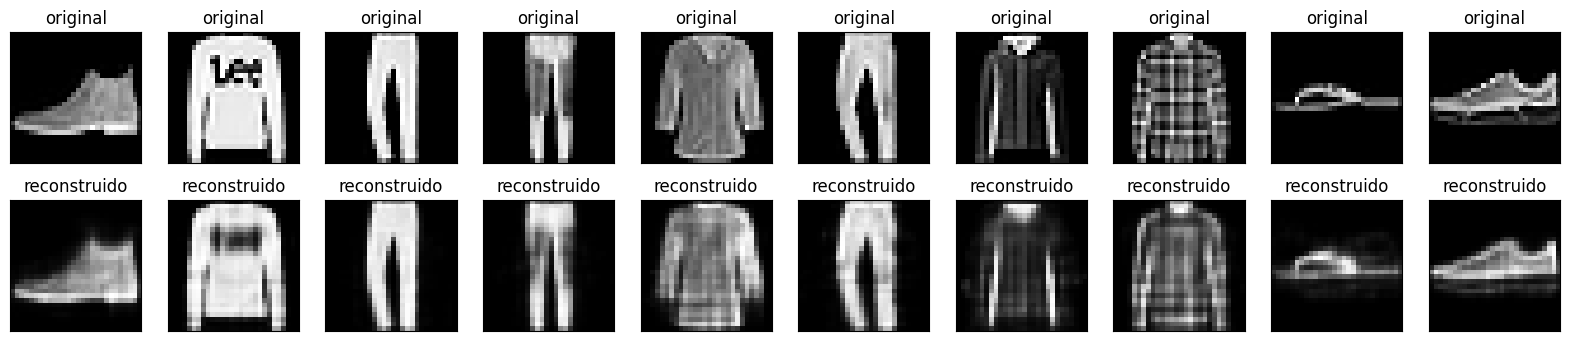

In [52]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
  # display original
  ax = plt.subplot(2, n, i + 1)
  plt.imshow(x_test[i])
  plt.title("original")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # display reconstruction
  ax = plt.subplot(2, n, i + 1 + n)
  plt.imshow(decoded_imgs[i])
  plt.title("reconstruido")
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

## Segundo Ejemplo: Eliminación de ruido en imágenes


<img src="/home/jordi/Documentos/Ribera/Curso_25_26/CEIABD/CEIABD_25_26/MODELOS_INTELIGENCIA_ARTIFICIAL_25_26/NOTEBOOKS DEL AULA/img/image_denoise_fmnist_results.png">

También se puede entrenar un autoencoder para eliminar el ruido de las imágenes.    
En la siguiente sección, se crea una versión "ruidosa" del dataset Fashion MNIST aplicando ruido aleatorio a cada imagen.    
A continuación, se entrena un autoencoder utilizando la imagen ruidosa como entrada y la imagen original como objetivo.

Se vuelve a importar el dataset para omitir las modificaciones realizadas previamente.

In [8]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

In [9]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(x_train.shape)

(60000, 28, 28, 1)


Añadiendo el ruido aleatorio a las imágenes.

In [10]:
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

Graficado de las imágenes con el ruido añadido


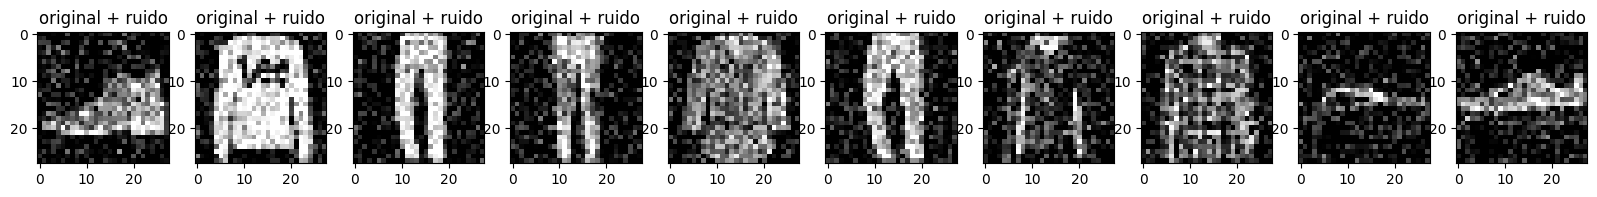

In [11]:
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.title("original + ruido")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
plt.show()

### Definición de un Autoencoder Convolucional

En este ejemplo, se usará un autoencoder convolucional usando capas [Conv2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D) en el `encoder`, y capas [Conv2DTranspose](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2DTranspose) en el `decoder`.

In [12]:
class Denoise(Model):
  def __init__(self):
    super(Denoise, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Input(shape=(28, 28, 1)),
      layers.Conv2D(16, (3, 3), activation='relu', padding='same', strides=2),
      layers.Conv2D(8, (3, 3), activation='relu', padding='same', strides=2)])

    self.decoder = tf.keras.Sequential([
      layers.Conv2DTranspose(8, kernel_size=3, strides=2, activation='relu', padding='same'),
      layers.Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'),
      layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = Denoise()

Compilación del Autoencoder Convolucional

In [13]:
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

Entrenamiento del modelo

In [14]:
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 0.0169 - val_loss: 0.0100
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0092 - val_loss: 0.0086
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0083 - val_loss: 0.0081
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0079 - val_loss: 0.0079
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0077 - val_loss: 0.0077
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0075 - val_loss: 0.0075
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0074 - val_loss: 0.0075
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0073 - val_loss: 0.0072
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0072 - val_loss: 0.0072
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0071 - val_loss: 0.0071


Si se muestra un resumen del codificador, se observa cómo las imágenes se reducen de 28x28 a 7x7.

In [15]:
autoencoder.encoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320 (5.16 KB)

 Trainable params: 1,320 (5.16 KB)

 Non-trainable params: 0 (0.00 B)

El descodificador aumenta la resolución de las imágenes de 7x7 a 28x28.

In [16]:
autoencoder.decoder.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ (32, 14, 14, 8)        │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (32, 28, 28, 16)       │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 28, 28, 1)        │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,897 (7.41 KB)

 Trainable params: 1,897 (7.41 KB)

 Non-trainable params: 0 (0.00 B)

Representación gráfica de las imágenes con ruido y de las imágenes "limpiadas" que genera el autoencoder.

In [17]:
# Se decodifican las imágenes ruidosas para compararlas con las originales
encoded_imgs = autoencoder.encoder(x_test_noisy).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

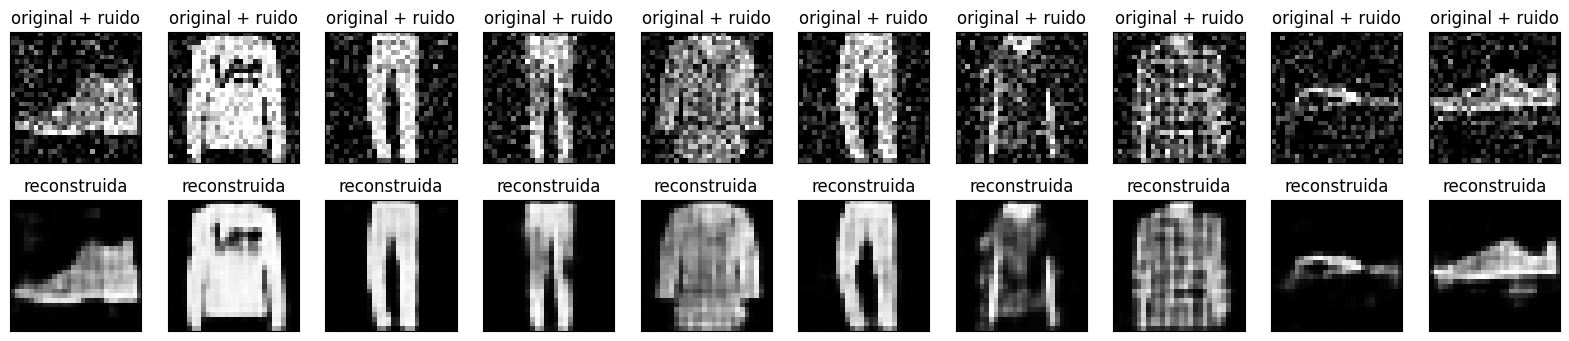

In [18]:
# Se grafican las imágenes originales, con ruido, y las reconstruidas
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    # display original + ruido
    ax = plt.subplot(2, n, i + 1)
    plt.title("original + ruido")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstrución
    bx = plt.subplot(2, n, i + n + 1)
    plt.title("reconstruida")
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    plt.gray()
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)
plt.show()

## Tercer Ejemplo: Detección de anomalías.

### Resumen


En este ejemplo, se entrena un autoencoder para detectar anomalías en el [dataset ECG5000](http://www.timeseriesclassification.com/description.php?Dataset=ECG5000). Este dataset contiene 5.000 [Electrocardiogramas](https://en.wikipedia.org/wiki/Electrocardiography), cada uno con 140 puntos de datos.    
Se utilizará una versión simplificada del dataset, en la que cada ejemplo se ha etiquetado como «0» (correspondiente a un ritmo anormal) o «1» (correspondiente a un ritmo normal).    

Lo que se pretende es identificar los **ritmos anormales**.

Nota: se trata de un dataset etiquetados, por lo que podría plantearse como un problema de aprendizaje supervisado. El objetivo de este ejemplo es ilustrar los conceptos de detección de anomalías que se pueden aplicar a datasets más grandes, en los que no se dispone de etiquetas (por ejemplo, si se tienen muchos miles de ritmos normales y sólo un pequeño número de ritmos anormales).

**¿Cómo se detectan las anomalías con un autoencoder?**   

Recordemos que un autoencoder se entrena para minimizar el error de reconstrucción. Se va a entrenar un autoencoder sólo con los ritmos normales y luego se utilizará para reconstruir todos los datos.   

La hipótesis de partida es que los ritmos anormales tendrán un mayor error de reconstrucción.    

A continuación, se clasificará un ritmo como anómalo si el error de reconstrucción supera un determinado umbral fijado.

### Carga del dataset con la información de los ECG

El dataset que se utilizará se basa en uno de la web [timeseriesclassification.com](http://www.timeseriesclassification.com/description.php?Dataset=ECG5000).

In [19]:
# Descarga del dataset
dataframe = pd.read_csv('http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv', header=None)
raw_data = dataframe.values
dataframe.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


Preparación de la información del dataset descargado

In [20]:
# La última columna contiene las etiquetas
labels = raw_data[:, -1]


# El resto de los datos son los datos del electrocardiograma
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)

Normalización de los datos al intervalo `[0,1]`.

In [21]:
min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)

Se entrena el autoencoder utilizando sólo los ritmos normales, que en este dataset se etiquetan como «1».    

A continuación, se separa los ritmos normales de los anormales.

In [22]:
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

Visualización de un ECG normal.

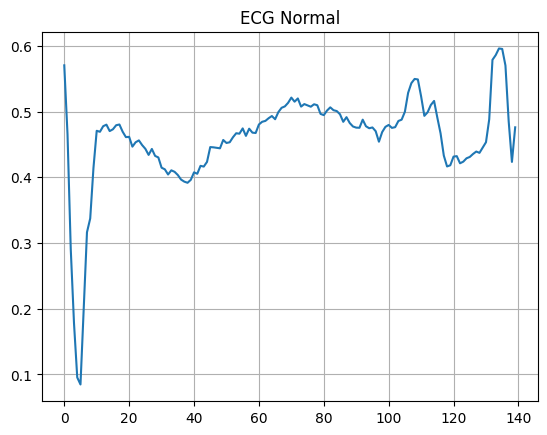

In [23]:
plt.grid()
plt.plot(np.arange(140), normal_train_data[0])
plt.title("ECG Normal")
plt.show()

Visualizar un ECG anómalo.

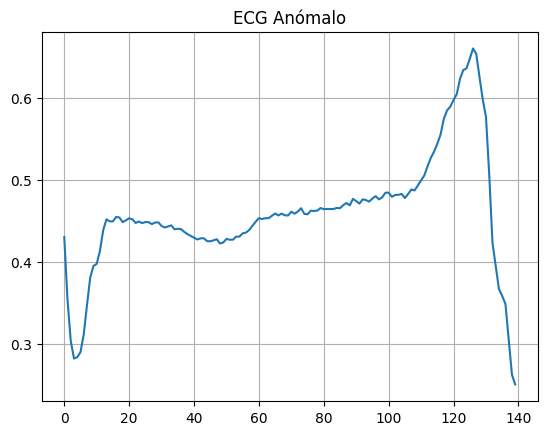

In [24]:
plt.grid()
plt.plot(np.arange(140), anomalous_train_data[0])
plt.title("ECG Anómalo")
plt.show()

### Construcción del modelo de detección de anomalías

In [25]:
class AnomalyDetector(Model):
  def __init__(self):
    super(AnomalyDetector, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Dense(32, activation="relu"),
      layers.Dense(16, activation="relu"),
      layers.Dense(8, activation="relu")])

    self.decoder = tf.keras.Sequential([
      layers.Dense(16, activation="relu"),
      layers.Dense(32, activation="relu"),
      layers.Dense(140, activation="sigmoid")])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AnomalyDetector()

Compilación del modelo

In [26]:
autoencoder.compile(optimizer='adam', loss='mae')

Obsérvese que el autoencoder se entrena utilizando sólo los ECG normales, pero se evalúa utilizando el conjunto de pruebas completo.

In [27]:
history = autoencoder.fit(normal_train_data, normal_train_data,
          epochs=20,
          batch_size=512,
          validation_data=(test_data, test_data),
          shuffle=True)

Epoch 1/20


2026-03-17 14:31:19.416211: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:31:22.259574: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_252', 72 bytes spill stores, 72 bytes spill loads



1/5 ━━━━━━━━━━━━━━━━━━━━ 40s 10s/step - loss: 0.0588

2026-03-17 14:31:27.616946: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:31:27.617092: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:31:27.617133: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:31:27.617243: I external/l

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.0582  

2026-03-17 14:31:41.447978: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:31:43.090755: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_56', 12 bytes spill stores, 12 bytes spill loads

2026-03-17 14:31:43.203023: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_56', 24 bytes spill stores, 24 bytes spill loads

2026-03-17 14:31:43.231691: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_56', 84 bytes sp

5/5 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - loss: 0.0578 - val_loss: 0.0532
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0557 - val_loss: 0.0519
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0528 - val_loss: 0.0501
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0495 - val_loss: 0.0482
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0462 - val_loss: 0.0463
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0429 - val_loss: 0.0445
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0396 - val_loss: 0.0426
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0364 - val_loss: 0.0411
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0334 - val_loss: 0.0397
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0308 - val_loss: 0.0384
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0286 - val_loss: 0.0375
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0268 - val_loss: 0.0368
Epoch 13/20
5

Visualización de métricas de evaluación de nuestro modelo.

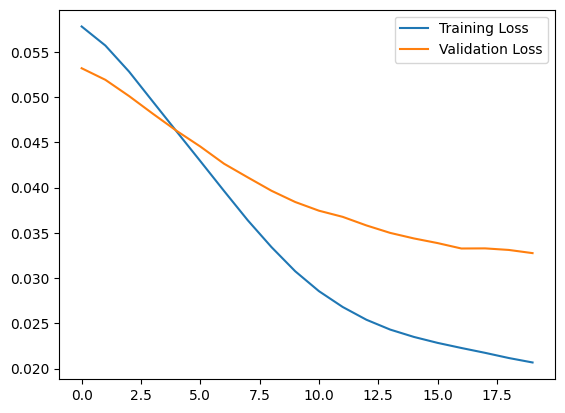

In [28]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

Se clasificará un ECG como anómalo si el error de reconstrucción es superior a una desviación estándar, respecto a los ejemplos de entrenamiento normales.    

En primer lugar, se va a mostrar un ECG normal del conjunto de entrenamiento, la reconstrucción después de ser codificado y decodificado por el autoencoder, y el error de reconstrucción.

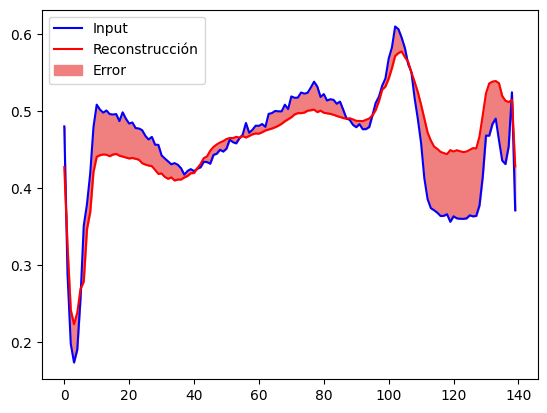

In [29]:
encoded_data = autoencoder.encoder(normal_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()

plt.plot(normal_test_data[0], 'b')
plt.plot(decoded_data[0], 'r')
plt.fill_between(np.arange(140), decoded_data[0], normal_test_data[0], color='lightcoral')
plt.legend(labels=["Input", "Reconstrucción", "Error"])
plt.show()

Ahora se crea un gráfico similar, esta vez para un ejemplo de prueba anómalo.

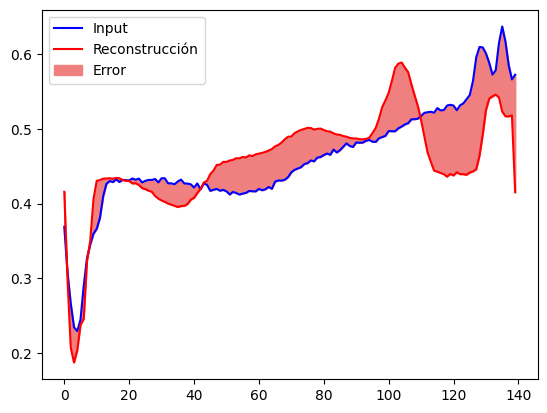

In [30]:
encoded_data = autoencoder.encoder(anomalous_test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()

plt.plot(anomalous_test_data[0], 'b')
plt.plot(decoded_data[0], 'r')
plt.fill_between(np.arange(140), decoded_data[0], anomalous_test_data[0], color='lightcoral')
plt.legend(labels=["Input", "Reconstrucción", "Error"])
plt.show()

### Detectando anomalias

Se detectan las anomalías calculando si la pérdida de reconstrucción es mayor que un umbral determinado.    

En este caso, se calculará el error medio promedio de los ejemplos normales del conjunto de entrenamiento y, a continuación, se clasificarán los ejemplos futuros como anómalos si el error de reconstrucción es superior a una desviación estándar del conjunto de entrenamiento.

Gráfico del error de reconstrucción en ECG normales del conjunto de entrenamiento

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


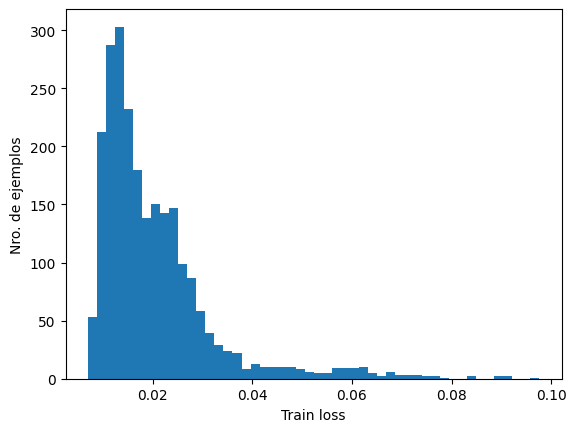

In [36]:
reconstructions = autoencoder.predict(normal_train_data)
train_loss = tf.keras.losses.mae(reconstructions, normal_train_data)

plt.hist(train_loss.numpy(), bins=50)
plt.xlabel("Train loss")
plt.ylabel("Nro. de ejemplos")
plt.show()

Se selecciona un valor umbral que esté una desviación estándar por encima de la media.

In [32]:
threshold = np.mean(train_loss) + np.std(train_loss)
print("Umbral: ", threshold)

Umbral:  0.032186247


Nota: Existen otras estrategias que podría utilizar para seleccionar un valor umbral por encima del cual los ejemplos de prueba deberían clasificarse como anómalos. El enfoque correcto dependerá de su conjunto de datos.

Si se analiza el error de reconstrucción de los ejemplos anómalos del conjunto de prueba, se observa que la mayoría tiene un error de reconstrucción mayor que el umbral. Variando el umbral, es posible ajustar la [precisión](https://developers.google.com/machine-learning/glossary#precision) y la [recall](https://developers.google.com/machine-learning/glossary#recall) del clasificador.

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


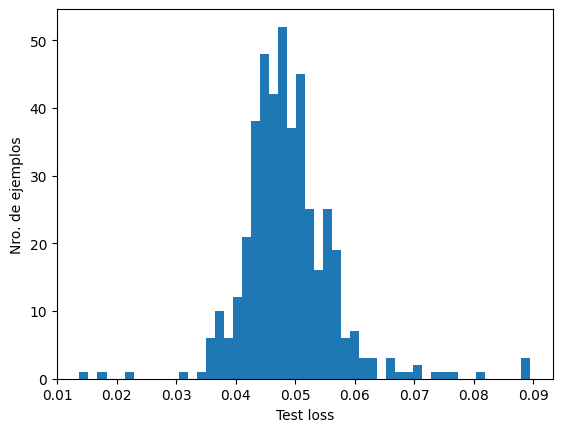

In [37]:
reconstructions = autoencoder.predict(anomalous_test_data)
test_loss = tf.keras.losses.mae(reconstructions, anomalous_test_data)

plt.hist(test_loss.numpy(), bins=50)
plt.xlabel("Test loss")
plt.ylabel("Nro. de ejemplos")
plt.show()

Finalmente, se preparan las funciones que van a evaluar el modelo, en el que se considera a un ECG como anomalía si el error de reconstrucción es superior al umbral establecido.

In [34]:
def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.less(loss, threshold)

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

In [38]:
preds = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.943
Precision = 0.9921722113502935
Recall = 0.9053571428571429


## Para saber más...

Para aprender más sobre la detección de anomalías con autoencoders, echa un vistazo a este excelente [ejemplo interactivo](https://anomagram.fastforwardlabs.com/#/) construido con TensorFlow.js por Victor Dibia. Para un caso de uso en el mundo real, puedes aprender cómo [Airbus Detects Anomalies in ISS Telemetry Data](https://blog.tensorflow.org/2020/04/how-airbus-detects-anomalies-iss-telemetry-data-tfx.html) usando TensorFlow. Para obtener más información sobre los conceptos básicos, se recomienda la posibilidad de leer esta [entrada de blog](https://blog.keras.io/building-autoencoders-in-keras.html) de François Chollet.


# Cuarto Ejemplo - Reducción de dimensionalidad.    

Para esta demostración se va a utilizar el conjunto de datos de Kaggle denominado [Rain in Australia](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package). El desarrollo, en esta ocasión, se realiza con la librería `PyTorch`.    

En primer lugar, se importan todas las bibliotecas necesarias y se eliminan los valores que faltan y las columnas no numéricas.

In [39]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv("/home/jordi/Documentos/Ribera/Curso_25_26/CEIABD/CEIABD_25_26/MODELOS_INTELIGENCIA_ARTIFICIAL_25_26/NOTEBOOKS DEL AULA/datasets/weatherAUS.csv")
df = df.drop(['Date', 'Location', 'WindDir9am',
             'WindGustDir', 'WindDir3pm'], axis=1)
df = df.dropna(how = 'any')
df.loc[df['RainToday'] == 'No', 'RainToday'] = 0
df.loc[df['RainToday'] == 'Yes', 'RainToday'] = 1
df.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
6049,17.9,35.2,0.0,12.0,12.3,48.0,6.0,20.0,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,0,No
6050,18.4,28.9,0.0,14.8,13.0,37.0,19.0,19.0,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0,0,No
6052,19.4,37.6,0.0,10.8,10.6,46.0,30.0,15.0,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9,0,No
6053,21.9,38.4,0.0,11.4,12.2,31.0,6.0,6.0,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6,0,No
6054,24.2,41.0,0.0,11.2,8.4,35.0,17.0,13.0,19.0,15.0,1010.7,1007.4,1.0,6.0,33.6,37.6,0,No


Ahora se procede a dividir los datos en características y etiquetas, normalizar las características y convertir las etiquetas a un formato numérico.

En este caso, se dispone de un conjunto de características inicial compuesto por 17 columnas. El objetivo general del análisis sería entonces predecir correctamente si va a llover al día siguiente o no.

In [40]:
X, Y = df.drop('RainTomorrow', axis=1, inplace=False), df[['RainTomorrow']]
# Normalizing Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Converting to PyTorch tensor
X_tensor = torch.FloatTensor(X_scaled)

# Converting string labels to numerical labels
label_encoder = LabelEncoder()
Y_numerical = label_encoder.fit_transform(Y.values.ravel())

En PyTorch, ahora es posible definir el modelo Autoencoder como una clase y especificar los modelos codificador y decodificador con dos capas lineales.

In [41]:
# Definición del modelo Autoencoder
class Autoencoder(nn.Module):
   def __init__(self, input_size, encoding_dim):
       super(Autoencoder, self).__init__()
       self.encoder = nn.Sequential(
           nn.Linear(input_size, 16),
           nn.ReLU(),
           nn.Linear(16, encoding_dim),
           nn.ReLU()
       )
       self.decoder = nn.Sequential(
           nn.Linear(encoding_dim, 16),
           nn.ReLU(),
           nn.Linear(16, input_size),
           nn.Sigmoid()
       )

   def forward(self, x):
       x = self.encoder(x)
       x = self.decoder(x)
       return x

Con el modelo configurado, se procede a especificar que las dimensiones de codificación sean iguales a 3 (para facilitar su trazado más adelante) y ejecutar el proceso de entrenamiento.

In [42]:
# Estableciendo la semilla aleatoria para reproducibilidad
torch.manual_seed(42)

input_size = X.shape[1]  # Número de características de entrada
encoding_dim = 3  # Dimensión deseada de las características codificadas
model = Autoencoder(input_size, encoding_dim)

# Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

# Entrenando el autoencoder
num_epochs = 20
for epoch in range(num_epochs):
   # Paso hacia adelante
   outputs = model(X_tensor)
   loss = criterion(outputs, X_tensor)

   # Paso hacia atrás y optimización
   optimizer.zero_grad()
   loss.backward()
   optimizer.step()

   # Perdida para cada época
   print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

# Codificando los datos utilizando el autoencoder entrenado
encoded_data = model.encoder(X_tensor).detach().numpy()

Epoch [1/20], Loss: 1.2443
Epoch [2/20], Loss: 1.2410
Epoch [3/20], Loss: 1.2376
Epoch [4/20], Loss: 1.2342
Epoch [5/20], Loss: 1.2307
Epoch [6/20], Loss: 1.2271
Epoch [7/20], Loss: 1.2234
Epoch [8/20], Loss: 1.2196
Epoch [9/20], Loss: 1.2156
Epoch [10/20], Loss: 1.2114
Epoch [11/20], Loss: 1.2070
Epoch [12/20], Loss: 1.2023
Epoch [13/20], Loss: 1.1974
Epoch [14/20], Loss: 1.1923
Epoch [15/20], Loss: 1.1868
Epoch [16/20], Loss: 1.1811
Epoch [17/20], Loss: 1.1751
Epoch [18/20], Loss: 1.1688
Epoch [19/20], Loss: 1.1622
Epoch [20/20], Loss: 1.1554


Por último, ahora es posible trazar las dimensiones de incrustación resultantes. Como puede verse en la imagen de abajo, se consigue reducir la dimensionalidad del conjunto de características de 17 dimensiones a sólo 3, sin dejar de ser capaces, en buena medida, de separar correctamente en el espacio tridimensional las muestras entre las distintas clases.

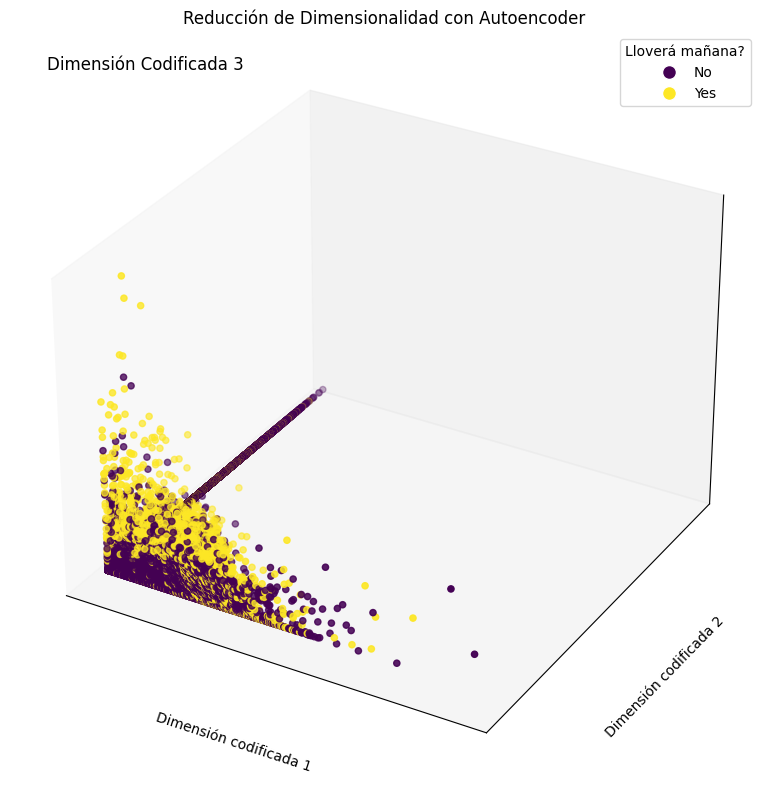

In [43]:
# Graficando los datos codificados en 3D con colores según las etiquetas originales
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(encoded_data[:, 0], encoded_data[:, 1],
                    encoded_data[:, 2], c=Y_numerical, cmap='viridis')

# Mapeando los números de las etiquetas a sus correspondientes etiquetas de texto para la leyenda
labels = label_encoder.inverse_transform(np.unique(Y_numerical))
legend_labels = {num: label for num, label in zip(np.unique(Y_numerical),
                                                 labels)}

# Creando leyenda personalizada para mostrar las etiquetas de texto en lugar de los números
handles = [plt.Line2D([0], [0], marker='o', color='w',
                    markerfacecolor=scatter.to_rgba(num),
                    markersize=10,
                    label=legend_labels[num]) for num in np.unique(Y_numerical)]
ax.legend(handles=handles, title="Lloverá mañana?")

# Ajustando los márgenes para mejorar la visibilidad de las etiquetas
ax.xaxis.labelpad = 20
ax.yaxis.labelpad = 20

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Añadiendo manualmente la etiqueta del eje z para mejorar su visibilidad.
ax.text2D(0.05, 0.95, 'Dimensión Codificada 3', transform=ax.transAxes,
         fontsize=12, color='black')

ax.set_xlabel('Dimensión codificada 1')
ax.set_ylabel('Dimensión codificada 2')
ax.set_title('Reducción de Dimensionalidad con Autoencoder')

plt.tight_layout()

plt.savefig('Rain_Prediction_Autoencoder.png')

plt.show()

# Conclusión.   

Los **autoencoders** pueden ser una herramienta realmente flexible para potenciar diferentes formas de casos de uso. En particular, los **autoencoders variacionales (VAE)** y la creación de las **GAN** abrieron la puerta al desarrollo de la IA Generativa, ofreciéndonos los primeros atisbos de cómo se puede utilizar la IA para generar nuevas formas de contenido nunca vistas.

### NOTA:

**VAE-AutoEncoder Variacional**: Mientras que los autoencoders estándar asignan entradas a representaciones latentes fijas, los VAE introducen un enfoque probabilístico en el que el codificador emite una distribución sobre el espacio latente, típicamente modelada como una gaussiana multivariante. Esto permite a los VAE tomar muestras de esta distribución durante el proceso de descodificación, lo que conduce a la generación de nuevas instancias de datos.

La innovación clave de los VAE reside en su capacidad para generar nuevos datos de alta calidad mediante el aprendizaje de un espacio latente estructurado y continuo. Esto es especialmente importante para el modelado generativo, donde el objetivo no es sólo comprimir datos, sino crear nuevas muestras de datos que se parezcan al conjunto de datos original. 

Los VAE han demostrado una eficacia significativa en tareas como la síntesis de imágenes, la eliminación de ruido de los datos y la detección de anomalías, lo que las convierte en herramientas relevantes para hacer avanzar las capacidades de los modelos y aplicaciones de aprendizaje automático.